In [58]:
import torch
# print(torch.cuda.is_available())
# print(torch.cuda.get_device_name())
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cam_pt_dir = r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\data\dataset\*.pt"
pt_files = sorted(glob.glob(cam_pt_dir))

degree_only = []
posture_only = []
all_feat = []

for f in pt_files:
    data = torch.load(f, weights_only=False)
    # upper_body = feats[:, :11, :]
    upper = data['landmarks'][:, :11, :]
    pos_feats = upper.reshape(upper.shape[0], -1).numpy()
    posture_only.append(pos_feats)

    deg_feats = data['features'].reshape(data['features'].shape[0], -1).numpy()
    degree_only.append(deg_feats)
    
    combined_feat = np.hstack([pos_feats, deg_feats])
    all_feat.append(combined_feat)
    
    
X_all = np.vstack(all_feat)
X_pos = np.vstack(posture_only)
X_deg = np.vstack(degree_only)

scaler = StandardScaler()

X_scaled_all = scaler.fit_transform(X_all)
X_scaled_pos = scaler.fit_transform(X_pos)
X_scaled_deg = scaler.fit_transform(X_deg)



print("Feature shape:", X_scaled_all.shape)
print("Posture feature shape:", X_scaled_pos.shape)
print("Degree feature shape:", X_scaled_deg.shape)


Feature shape: (16250, 31)
Posture feature shape: (16250, 22)
Degree feature shape: (16250, 9)


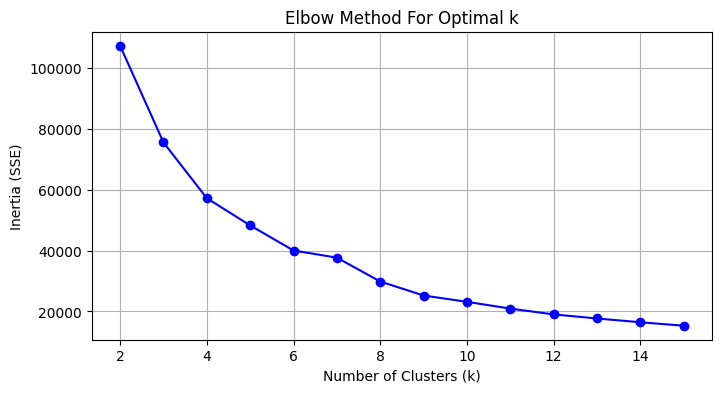

In [59]:
inertias = []
K_range = range(2, 16) #

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_deg)
    inertias.append(kmeans.inertia_)

#
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [19]:
# test 6
optimal_k = 3 

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

counts = np.bincount(labels)
for i, c in enumerate(counts):
    print(f"cluster {i}: {c} {c/len(labels)*100:.1f}%")

cluster 0: 11277 69.4%
cluster 1: 2782 17.1%
cluster 2: 2191 13.5%


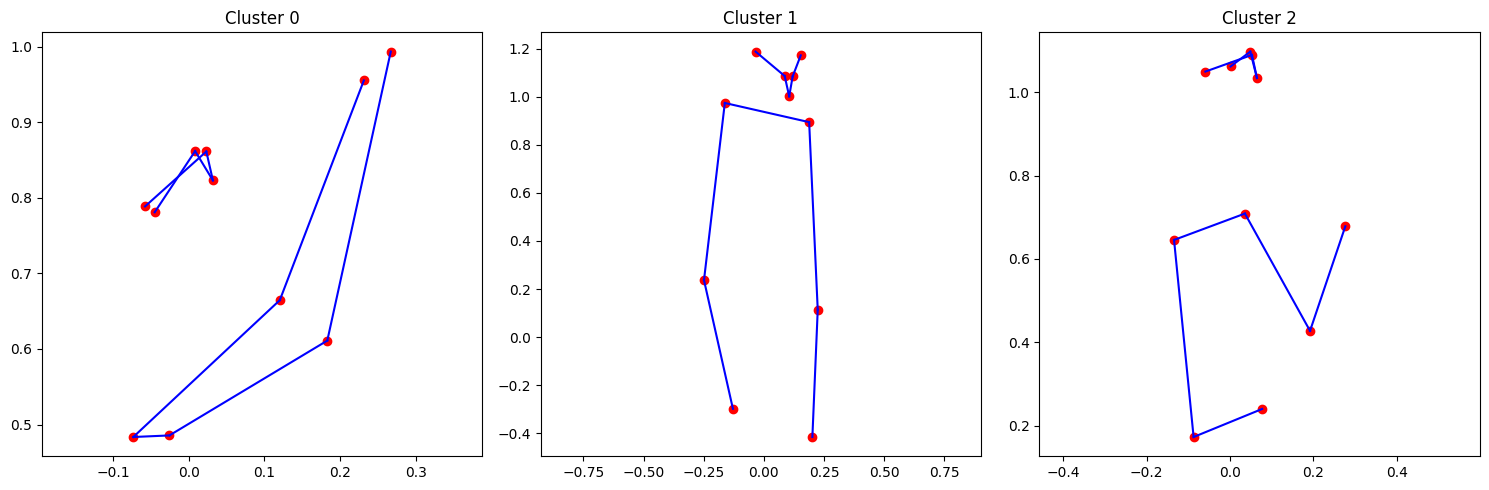

In [20]:
def plot_skeleton(points, title):
    EDGES = [(0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), 
             (8, 10)]
    
    pts = points.reshape(11, 2)
    plt.scatter(pts[:, 0], -pts[:, 1], c='red') 
    for edge in EDGES:
        plt.plot([pts[edge[0], 0], pts[edge[1], 0]], 
                 [-pts[edge[0], 1], -pts[edge[1], 1]], 'b-')
    plt.title(title)
    plt.axis('equal')

plt.figure(figsize=(15, 5))
for i in range(optimal_k):
    plt.subplot(1, optimal_k, i+1)
    plot_skeleton(kmeans.cluster_centers_[i], f"Cluster {i}")
plt.tight_layout()
plt.show()

In [37]:
def plot_hybrid_feature_heatmap(X_stacked, data_path, n_clusters=5, target_steps=100):
    # get all .pt files
    pt_files = sorted(glob.glob(os.path.join(data_path, "*.pt")))
    if not pt_files:
        print(".pt files not found in the specified directory.")
        return

    # 2. global K-Means clustering on the stacked features
    print("Performing K-Means clustering on combined features...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    global_labels = kmeans.fit_predict(X_stacked)

    # 3. construct parallel matrix for each video
    parallel_matrix = []
    video_names = []
    current_ptr = 0 #

    for pf in pt_files:
        data = torch.load(pf, weights_only=False)
        video_name = os.path.basename(pf).replace(".pt", "")
        
        # get number of frames for this video
        num_frames = data['landmarks'].shape[0]
        
        # extract corresponding cluster labels for this video's frames
        video_labels = global_labels[current_ptr : current_ptr + num_frames]
        current_ptr += num_frames
        
        # align (Resampling to 0-100%)
        if len(video_labels) > 0:
            indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
            resampled_labels = video_labels[indices]
            
            parallel_matrix.append(resampled_labels)
            video_names.append(video_name)

    # 4. plot heatmap
    parallel_matrix = np.array(parallel_matrix)
    plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))
    
    cmap = plt.get_cmap("tab20", n_clusters)
    sns.heatmap(parallel_matrix, 
                cmap=cmap, 
                xticklabels=10, 
                yticklabels=video_names,
                cbar_kws={'label': 'Cluster ID', 'ticks': range(n_clusters)})

    plt.title(f"Hybrid Feature Pattern Analysis (K={n_clusters})", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples", fontsize=12)
    
    # 5% interval ticks
    plt.xticks(np.linspace(0, target_steps, 21), [f"{i*5}%" for i in range(21)])
    
    plt.tight_layout()
    plt.show()

    return kmeans, parallel_matrix

In [45]:
pt_path = r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\data\dataset"

Performing K-Means clustering on combined features...


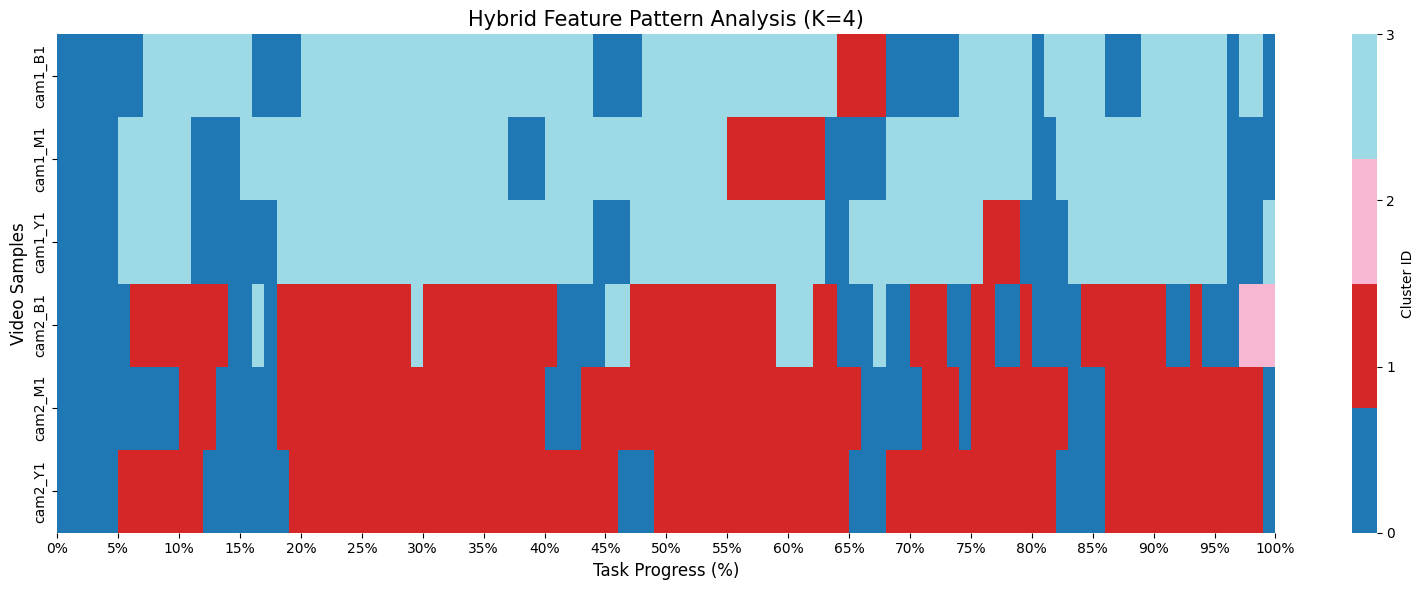

In [65]:
#posture + degree
kmeans_all, parallel_matrix_all = plot_hybrid_feature_heatmap(X_scaled_all, pt_path, n_clusters=4)

Performing K-Means clustering on combined features...


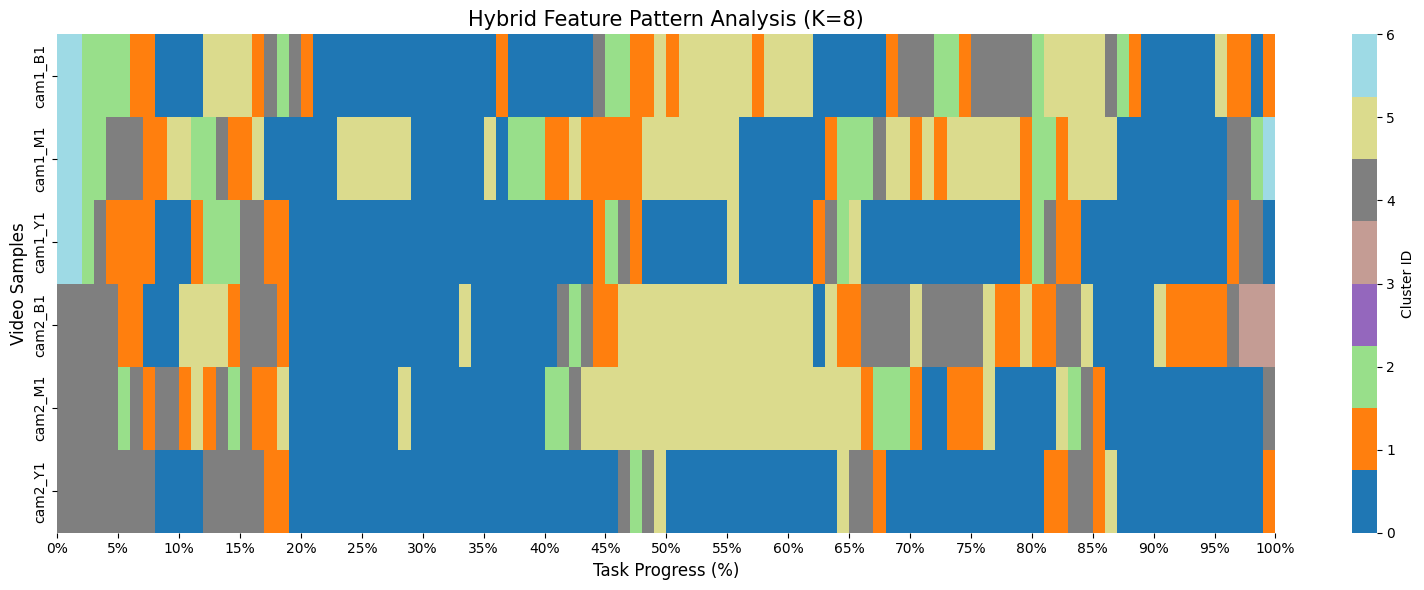

In [67]:
#degree only
kmeans_deg, parallel_matrix_deg = plot_hybrid_feature_heatmap(X_scaled_deg, pt_path, n_clusters=8)

Performing K-Means clustering on combined features...


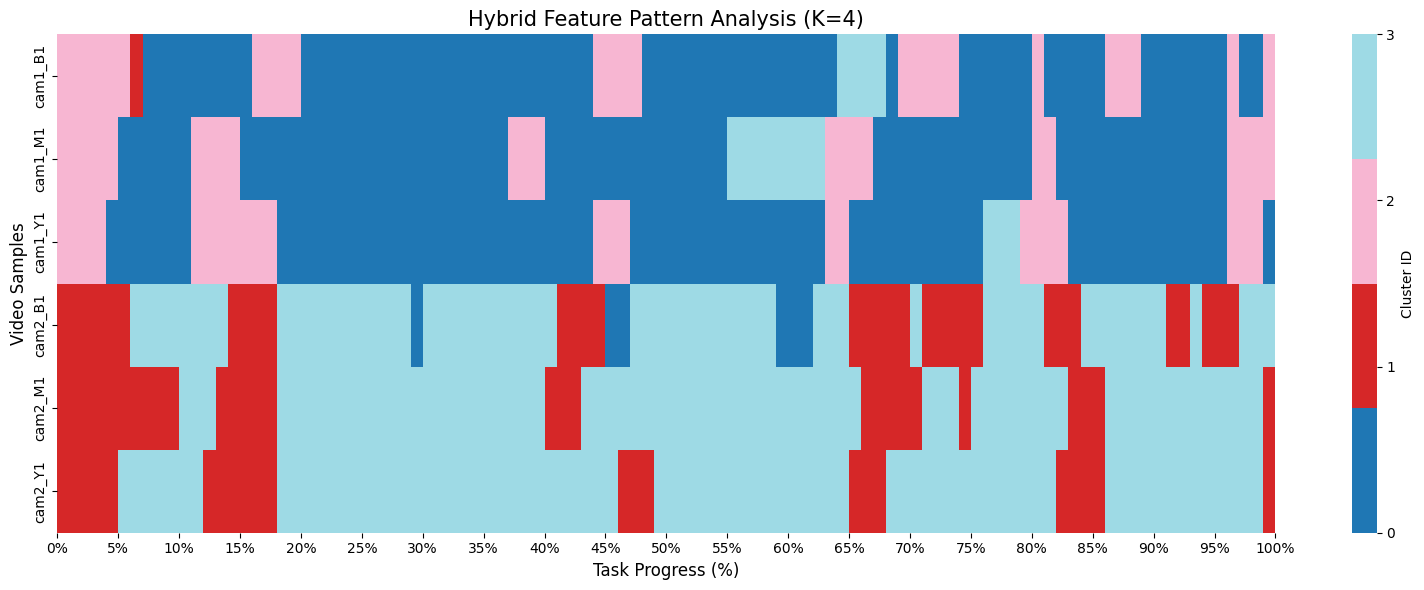

In [66]:
#posture only
kmeans_pos, parallel_matrix_pos = plot_hybrid_feature_heatmap(X_scaled_pos, pt_path, n_clusters=4)